# Final Submission - Credit Score Data Mining

This notebook skeleton follows the required 10-section contract.

## 1. Imports and Configuration

In [1]:
import sys
import subprocess

print('Kernel Python:', sys.executable)
try:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'])
except Exception as e:
    print('requirements.txt install failed, fallback to minimal packages:', e)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'jupyter', 'notebook', 'ipykernel'])
print('Dependency bootstrap completed.')

Kernel Python: c:\Users\ASUS\miniconda3\python.exe
requirements.txt install failed, fallback to minimal packages: Command '['c:\\Users\\ASUS\\miniconda3\\python.exe', '-m', 'pip', 'install', '-r', 'requirements.txt']' returned non-zero exit status 1.
Dependency bootstrap completed.


In [2]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

import time

NOTEBOOK_START_TIME = time.perf_counter()
BLOCK_TIMES = []

def timer_start(block_name):
    print(f"[TIMER] START: {block_name}")
    return time.perf_counter()

def timer_end(block_name, t0):
    elapsed = time.perf_counter() - t0
    BLOCK_TIMES.append((block_name, elapsed))
    print(f"[TIMER] END: {block_name} - {elapsed:.2f}s")


RUN_FULL_CLASSIFICATION = True
RUN_FULL_CLUSTERING = True

LEAKAGE_STRATEGY = 'deduplicate_customer'  # deduplicate_customer | single_month
SINGLE_MONTH_VALUE = None

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / 'data' / 'raw' / 'train.csv').exists() else None
if PROJECT_ROOT is None:
    for _p in _cwd.parents:
        if (_p / 'data' / 'raw' / 'train.csv').exists():
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Cannot locate project root containing data/raw/train.csv')

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'train.csv'
CLEAN_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_credit_data.csv'
TARGET_COL = 'Credit_Score'
ID_COLS = ['ID', 'Customer_ID', 'Month', 'Name', 'SSN']
OPTIONAL_DROP_COLS = ['Type_of_Loan']

print('SEED=', SEED)
print('LEAKAGE_STRATEGY=', LEAKAGE_STRATEGY)
print('PROJECT_ROOT=', PROJECT_ROOT)

SEED= 42
LEAKAGE_STRATEGY= deduplicate_customer
PROJECT_ROOT= d:\data-mining-credit-score


## 2. Load Raw Data

In [3]:
__block_name = "2. Load Raw Data"
__t0 = timer_start(__block_name)
try:
    if not RAW_PATH.exists():
        raise FileNotFoundError(f'Raw dataset not found: {RAW_PATH}')
    df_raw = pd.read_csv(RAW_PATH)
    print('Raw shape:', df_raw.shape)
    print('Columns:', df_raw.columns.tolist())
    if TARGET_COL in df_raw.columns:
        print('Target classes:', sorted(df_raw[TARGET_COL].dropna().astype(str).unique().tolist()))
finally:
    timer_end(__block_name, __t0)

[TIMER] START: 2. Load Raw Data
Raw shape: (100000, 28)
Columns: ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']
Target classes: ['Good', 'Poor', 'Standard']
[TIMER] END: 2. Load Raw Data - 0.93s


## 3. Preprocessing and Leakage Handling

In [4]:
__block_name = "3. Preprocessing and Leakage Handling"
__t0 = timer_start(__block_name)
try:
    df_prep = df_raw.copy()
    shape_before = df_prep.shape
    
    if LEAKAGE_STRATEGY == 'single_month':
        if SINGLE_MONTH_VALUE is None:
            raise ValueError('Set SINGLE_MONTH_VALUE for single_month strategy')
        df_prep = df_prep[df_prep['Month'].astype(str) == str(SINGLE_MONTH_VALUE)].copy()
    elif LEAKAGE_STRATEGY == 'deduplicate_customer':
        df_prep = df_prep.drop_duplicates(subset=['Customer_ID'], keep='first').copy()
    else:
        raise ValueError('Unsupported LEAKAGE_STRATEGY')
    
    shape_after_leakage = df_prep.shape
    drop_cols = [c for c in (ID_COLS + OPTIONAL_DROP_COLS) if c in df_prep.columns]
    df_prep = df_prep.drop(columns=drop_cols, errors='ignore')
    
    continuous_candidates = [
        'Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card',
        'Interest_Rate','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment',
        'Changed_Credit_Limit','Num_Credit_Inquiries','Outstanding_Debt','Credit_Utilization_Ratio',
        'Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance'
    ]
    
    for col in continuous_candidates:
        if col in df_prep.columns:
            df_prep[col] = pd.to_numeric(df_prep[col].astype(str).str.replace('_','', regex=False).str.replace(',','', regex=False), errors='coerce')
    
    if 'Age' in df_prep.columns:
        df_prep = df_prep[df_prep['Age'].fillna(0) > 0].copy()
    
    numeric_cols = df_prep.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())
    
    object_cols = df_prep.select_dtypes(include=['object']).columns.tolist()
    for col in object_cols:
        mode_val = df_prep[col].mode(dropna=True)
        fill_val = mode_val.iloc[0] if len(mode_val) > 0 else 'Unknown'
        df_prep[col] = df_prep[col].fillna(fill_val)
    
    label_encoders = {}
    categorical_cols = [c for c in df_prep.select_dtypes(include=['object']).columns if c != TARGET_COL]
    for col in categorical_cols:
        le = LabelEncoder()
        df_prep[col] = le.fit_transform(df_prep[col].astype(str))
        label_encoders[col] = le
    
    continuous_features = [c for c in continuous_candidates if c in df_prep.columns]
    print('Shape before preprocessing:', shape_before)
    print('Shape after leakage handling:', shape_after_leakage)
    print('Shape after preprocessing:', df_prep.shape)
finally:
    timer_end(__block_name, __t0)

[TIMER] START: 3. Preprocessing and Leakage Handling
Shape before preprocessing: (100000, 28)
Shape after leakage handling: (12500, 28)
Shape after preprocessing: (12500, 22)
[TIMER] END: 3. Preprocessing and Leakage Handling - 0.74s


## 4. Save Cleaned CSV

In [5]:
__block_name = "4. Save Cleaned CSV"
__t0 = timer_start(__block_name)
try:
    CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_prep.to_csv(CLEAN_PATH, index=False)
    print('Saved cleaned data to:', CLEAN_PATH)
    print('Saved shape:', df_prep.shape)
finally:
    timer_end(__block_name, __t0)

[TIMER] START: 4. Save Cleaned CSV
Saved cleaned data to: d:\data-mining-credit-score\data\processed\cleaned_credit_data.csv
Saved shape: (12500, 22)
[TIMER] END: 4. Save Cleaned CSV - 0.47s


## 5. Reload Cleaned CSV

In [6]:
__block_name = "5. Reload Cleaned CSV"
__t0 = timer_start(__block_name)
try:
    if not CLEAN_PATH.exists():
        raise FileNotFoundError(f'Cleaned dataset not found: {CLEAN_PATH}')
    cleaned_df = pd.read_csv(CLEAN_PATH)
    print('Reloaded cleaned shape:', cleaned_df.shape)
    cleaned_df.head()
finally:
    timer_end(__block_name, __t0)

[TIMER] START: 5. Reload Cleaned CSV
Reloaded cleaned shape: (12500, 22)
[TIMER] END: 5. Reload Cleaned CSV - 0.12s


## 6. EDA

In [7]:
__block_name = "6. EDA"
__t0 = timer_start(__block_name)
try:
    print('Shape:', cleaned_df.shape)
    print('Dtypes (first 30):')
    print(cleaned_df.dtypes.head(30))
    
    if TARGET_COL in cleaned_df.columns:
        print('Label distribution:')
        print(cleaned_df[TARGET_COL].value_counts(dropna=False))
    
    eda_continuous_cols = [c for c in continuous_features if c in cleaned_df.columns]
    if not eda_continuous_cols:
        eda_continuous_cols = [c for c in cleaned_df.select_dtypes(include=[np.number]).columns if c != TARGET_COL]
    
    if len(eda_continuous_cols) > 0:
        desc_stats = cleaned_df[eda_continuous_cols].describe().T[['min', 'max', 'mean']].sort_index()
        print('Continuous stats (min/max/mean):')
        print(desc_stats)
    else:
        print('No continuous columns available for descriptive stats.')
finally:
    timer_end(__block_name, __t0)

[TIMER] START: 6. EDA
Shape: (12500, 22)
Dtypes (first 30):
Age                         float64
Occupation                    int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate               float64
Num_of_Loan                 float64
Delay_from_due_date         float64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                    int64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount         int64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour             int64
Monthly_Balance             float64
Credit_Score                    str
dtype: object
Label distribution:
Credit_Score
Standard    6943
Poor        3582
Good        1975
Name: count, dtype: int64
Continuous stats (min/ma

## 7. PCA Visualization

[TIMER] START: 7. PCA Visualization


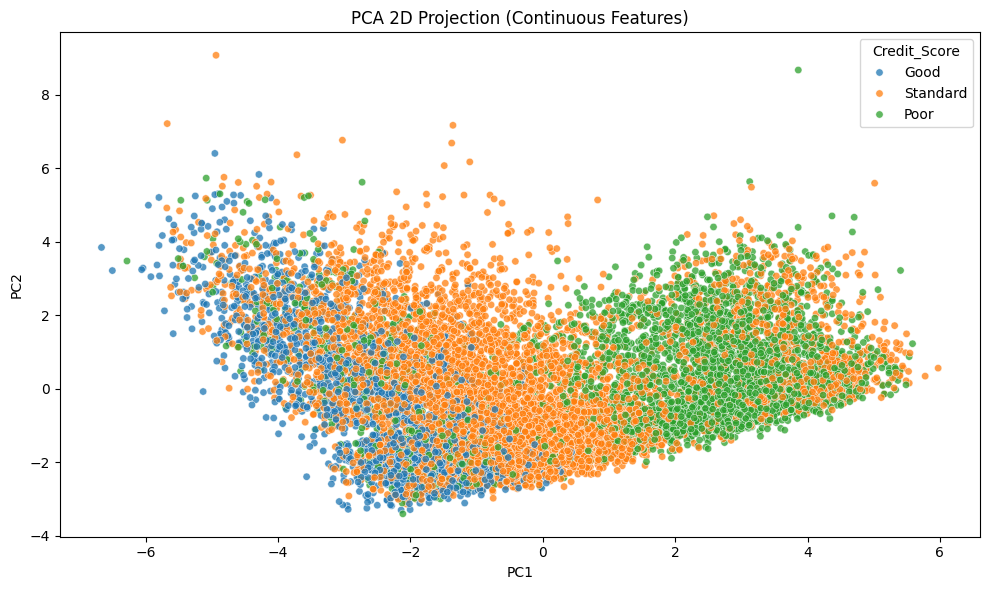

Explained variance ratio: [0.37883205 0.17670815]
[TIMER] END: 7. PCA Visualization - 1.32s


In [8]:
__block_name = "7. PCA Visualization"
__t0 = timer_start(__block_name)
try:
    pca_features = [c for c in eda_continuous_cols if c != TARGET_COL]
    if len(pca_features) < 2:
        print('Not enough continuous features for PCA(2).')
    else:
        X_scaled = StandardScaler().fit_transform(cleaned_df[pca_features])
        pca = PCA(n_components=2, random_state=SEED)
        X_2d = pca.fit_transform(X_scaled)
        pca_df = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
        if TARGET_COL in cleaned_df.columns:
            pca_df[TARGET_COL] = cleaned_df[TARGET_COL].astype(str).values
    
        plt.figure(figsize=(10, 6))
        if TARGET_COL in pca_df.columns:
            sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=TARGET_COL, alpha=0.75, s=28)
        else:
            sns.scatterplot(data=pca_df, x='PC1', y='PC2', alpha=0.75, s=28)
        plt.title('PCA 2D Projection (Continuous Features)')
        plt.tight_layout()
        plt.show()
        print('Explained variance ratio:', pca.explained_variance_ratio_)
finally:
    timer_end(__block_name, __t0)

## 8. Classification (3 Tuned Models + 10-Fold CV)

Set RUN_FULL_CLASSIFICATION=True for full GridSearchCV.

In [9]:
__block_name = "8. Classification (3 Tuned Models + 10-Fold CV)"
__t0 = timer_start(__block_name)
try:
    if TARGET_COL not in cleaned_df.columns:
        raise ValueError(f'Target column not found: {TARGET_COL}')
    
    X_cls = cleaned_df.drop(columns=[TARGET_COL])
    y_cls = cleaned_df[TARGET_COL].astype(str)
    
    num_features = X_cls.select_dtypes(include=[np.number]).columns.tolist()
    cat_features = [c for c in X_cls.columns if c not in num_features]
    
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
    preprocessor = ColumnTransformer([('num', num_pipe, num_features), ('cat', cat_pipe, cat_features)])
    
    models = {
        'KNN': Pipeline([('preprocessor', preprocessor), ('classifier', KNeighborsClassifier())]),
        'RandomForest': Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=SEED))]),
        'SVM': Pipeline([('preprocessor', preprocessor), ('classifier', SVC(random_state=SEED))])
    }
    
    param_grids = {
        'KNN': {'classifier__n_neighbors': [5, 11], 'classifier__weights': ['uniform', 'distance'], 'classifier__p': [1, 2]},
        'RandomForest': {'classifier__n_estimators': [200, 400], 'classifier__max_depth': [None, 15], 'classifier__min_samples_split': [2, 10]},
        'SVM': {'classifier__C': [1, 10], 'classifier__kernel': ['rbf', 'linear'], 'classifier__gamma': ['scale', 'auto']}
    }
    
    cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
    
    if RUN_FULL_CLASSIFICATION:
        rows = []
        for model_name, model_pipe in models.items():
            print(f'Running GridSearchCV for {model_name}...')
            gs = GridSearchCV(model_pipe, param_grids[model_name], scoring='f1_macro', cv=cv10, n_jobs=-1, verbose=1)
            gs.fit(X_cls, y_cls)
            rows.append({'Model': model_name, 'Best_CV_F1_Macro': gs.best_score_, 'Best_Params': gs.best_params_})
        classification_results = pd.DataFrame(rows).sort_values('Best_CV_F1_Macro', ascending=False)
    else:
        classification_results = pd.DataFrame({
            'Model': ['KNN', 'RandomForest', 'SVM'],
            'Best_CV_F1_Macro': [np.nan, np.nan, np.nan],
            'Best_Params': ['TODO (set RUN_FULL_CLASSIFICATION=True)'] * 3
        })
        print('Full classification is skipped.')
    
    print(classification_results)
finally:
    timer_end(__block_name, __t0)

[TIMER] START: 8. Classification (3 Tuned Models + 10-Fold CV)
Running GridSearchCV for KNN...
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Running GridSearchCV for RandomForest...
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Running GridSearchCV for SVM...
Fitting 10 folds for each of 8 candidates, totalling 80 fits
          Model  Best_CV_F1_Macro  \
1  RandomForest          0.768926   
2           SVM          0.752663   
0           KNN          0.711620   

                                         Best_Params  
1  {'classifier__max_depth': 15, 'classifier__min...  
2  {'classifier__C': 1, 'classifier__gamma': 'sca...  
0  {'classifier__n_neighbors': 11, 'classifier__p...  
[TIMER] END: 8. Classification (3 Tuned Models + 10-Fold CV) - 572.50s


## 9. Clustering (KMeans + DBSCAN + ARI/NMI)

Set RUN_FULL_CLUSTERING=True for full clustering run.

In [10]:
__block_name = "9. Clustering (KMeans + DBSCAN + ARI/NMI)"
__t0 = timer_start(__block_name)
try:
    X_cluster = cleaned_df.drop(columns=[TARGET_COL], errors='ignore').copy()
    y_true = cleaned_df[TARGET_COL].astype(str) if TARGET_COL in cleaned_df.columns else None
    
    for col in X_cluster.columns:
        if X_cluster[col].dtype == 'object':
            X_cluster[col] = X_cluster[col].astype('category').cat.codes
    X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)
    X_cluster = X_cluster.fillna(X_cluster.median(numeric_only=True))
    
    if RUN_FULL_CLUSTERING:
        X_scaled_cluster = StandardScaler().fit_transform(X_cluster)
        kmeans_labels = KMeans(n_clusters=3, random_state=SEED, n_init=10).fit_predict(X_scaled_cluster)
        dbscan_labels = DBSCAN(eps=0.8, min_samples=10).fit_predict(X_scaled_cluster)
    
        if y_true is not None:
            clustering_results = pd.DataFrame([
                {'Algorithm': 'KMeans', 'ARI': adjusted_rand_score(y_true, kmeans_labels), 'NMI': normalized_mutual_info_score(y_true, kmeans_labels), 'Notes': 'n_clusters=3'},
                {'Algorithm': 'DBSCAN', 'ARI': adjusted_rand_score(y_true, dbscan_labels), 'NMI': normalized_mutual_info_score(y_true, dbscan_labels), 'Notes': 'eps=0.8, min_samples=10'}
            ])
        else:
            clustering_results = pd.DataFrame([
                {'Algorithm': 'KMeans', 'ARI': np.nan, 'NMI': np.nan, 'Notes': 'Target unavailable'},
                {'Algorithm': 'DBSCAN', 'ARI': np.nan, 'NMI': np.nan, 'Notes': 'Target unavailable'}
            ])
    else:
        clustering_results = pd.DataFrame([
            {'Algorithm': 'KMeans', 'ARI': np.nan, 'NMI': np.nan, 'Notes': 'TODO (set RUN_FULL_CLUSTERING=True)'},
            {'Algorithm': 'DBSCAN', 'ARI': np.nan, 'NMI': np.nan, 'Notes': 'TODO (set RUN_FULL_CLUSTERING=True)'}
        ])
        print('Full clustering is skipped.')
    
    print(clustering_results)
finally:
    timer_end(__block_name, __t0)

[TIMER] START: 9. Clustering (KMeans + DBSCAN + ARI/NMI)
  Algorithm       ARI       NMI                    Notes
0    KMeans  0.167158  0.191074             n_clusters=3
1    DBSCAN  0.000000  0.000000  eps=0.8, min_samples=10
[TIMER] END: 9. Clustering (KMeans + DBSCAN + ARI/NMI) - 6.47s


## 10. Conclusion

Fill this section after full execution:
- Leakage strategy and rationale
- EDA insights
- PCA interpretation
- Best classification model and tuned params
- KMeans vs DBSCAN comparison (ARI/NMI)
- Final recommendation and limitations

## Phụ lục - Tổng Kết Thời Gian Chạy

Bảng dưới đây tổng hợp thời gian thực thi theo từng khối và tổng thời gian toàn notebook.

In [11]:
__block_name = "Runtime Summary"
__t0 = timer_start(__block_name)
try:
    total_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
    timing_df = pd.DataFrame(BLOCK_TIMES, columns=["Block", "Seconds"])
    if len(timing_df) > 0:
        print("\nThời gian theo từng khối:")
        print(timing_df)
        print(f"\nTổng thời gian notebook: {total_elapsed:.2f}s")
    else:
        print("Chưa có dữ liệu thời gian. Hãy chạy lần lượt toàn bộ các cell.")
finally:
    timer_end(__block_name, __t0)

[TIMER] START: Runtime Summary

Thời gian theo từng khối:
                                             Block     Seconds
0                                 2. Load Raw Data    0.927378
1            3. Preprocessing and Leakage Handling    0.739833
2                              4. Save Cleaned CSV    0.465563
3                            5. Reload Cleaned CSV    0.123662
4                                           6. EDA    0.100794
5                             7. PCA Visualization    1.321326
6  8. Classification (3 Tuned Models + 10-Fold CV)  572.498807
7        9. Clustering (KMeans + DBSCAN + ARI/NMI)    6.465327

Tổng thời gian notebook: 619.68s
[TIMER] END: Runtime Summary - 0.02s
